<a href="https://colab.research.google.com/github/Putra1688/PCVK25_3G_22/blob/main/Week03_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<table border="1">
  <tr>
    <td>Nama</td>
    <td>Rangga Dwi Saputra</td>
  </tr>
  <tr>
    <td>NIM</td>
    <td>2341720248</td>
  </tr>
  <tr>
    <td>Kelas</td>
    <td>TI 3G</td>
  </tr>
  <tr>
    <td>Pertemuan</td>
    <td>3 - 12, September 2025</td>
  </tr>
</table>


## **D1 Operasi Citra Sederhana**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Transformasi Linier Brightness**

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-257933560.py:19: RuntimeWarning: overflow encountered in scalar add
  brightness_img[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


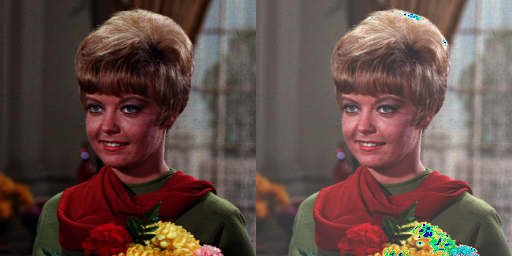

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError :
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/female.tiff')
brightness_img = np.zeros(original.shape, original.dtype)

#  akses per pixel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_img[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_img))
cv2_imshow(final_frame)

## **Tugas Praktikum D1**

**1. Citra Inverse**

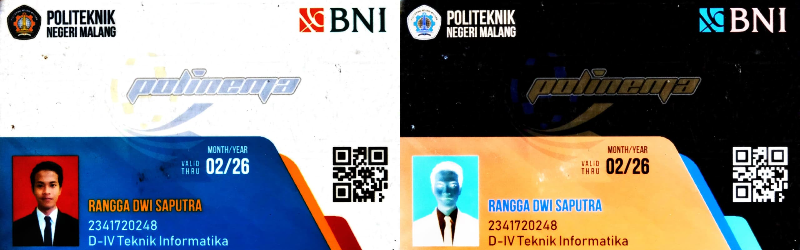

In [ ]:
asli = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/ktm.jpg')

#  resize dulu biar tidak terlalu besar
ktm = cv.resize(asli,(400,250))

# dicopy biar punya inverse dan asli
ktm_copy = ktm.copy()
inverse_ktm = 255 - ktm_copy

# Gabungkan secara horizontal (samping-sampingan)
comparison = np.hstack((ktm_copy, inverse_ktm))
cv2_imshow(comparison)

**2. Transformasi Contrast**

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan tingkat kecerahan [-255 sampai 255]: 50
Masukkan kontras [1.0 - 3.0]: 2


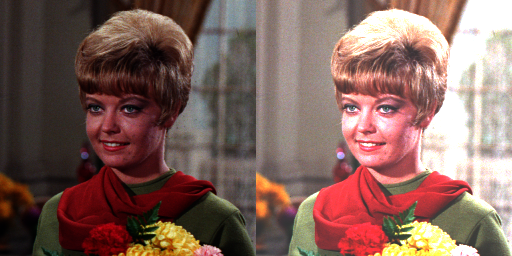

In [ ]:
print('Mengubah Kontras & tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan tingkat kecerahan [-255 sampai 255]: '))
  alpha = float(input('Masukkan kontras [1.0 - 3.0]: '))
except ValueError :
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/female.tiff')
contrast_brightness_img = np.zeros(original.shape, original.dtype)

#  akses per pixel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      contrast_brightness_img[y, x, c] = np.clip(
                alpha * original[y, x, c] + brightness, 0, 255
            )

final_frame = cv.hconcat((original, contrast_brightness_img))
cv2_imshow(final_frame)

**3. Transformasi Logarithmic Brightness**

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------
Masukkan tingkat kecerahan : 50


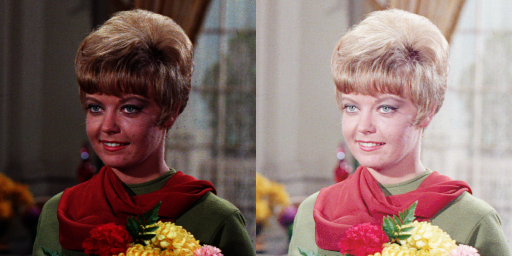

In [ ]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------')
try:
  brightness = int(input('Masukkan tingkat kecerahan : '))
except ValueError :
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/female.tiff')
# Tentukan konstanta c
c = 255 / np.log(1 + np.max(original))
log_img = np.zeros(original.shape, original.dtype)

# akses per pixel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for channel in range(original.shape[2]):
            log_img[y, x, channel] = np.clip(
                c * np.log(1 + original[y, x, channel]), 0, 255
            )

final_frame = cv.hconcat((original, log_img.astype(np.uint8)))
cv2_imshow(final_frame)

**4. Transformasi Grayscale**

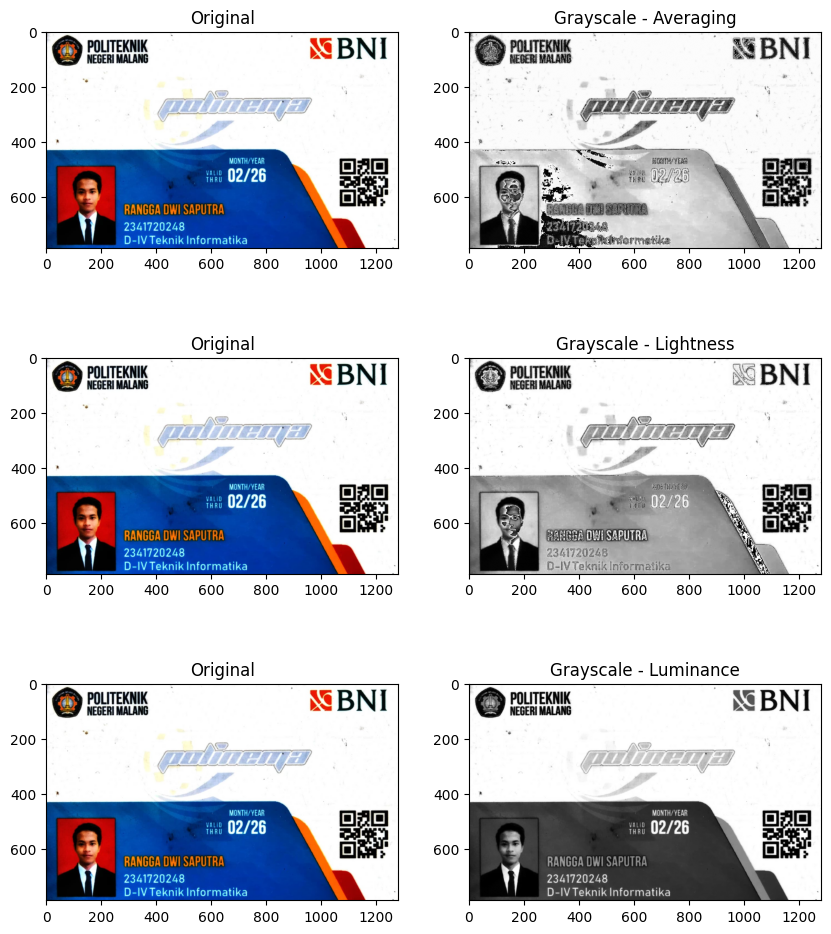

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar KTM
ktm = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/ktm.jpg')
ktm_rgb = cv.cvtColor(ktm, cv.COLOR_BGR2RGB)  # ubah ke RGB biar sesuai matplotlib

# Pisahkan channel
R = ktm_rgb[:,:,0]
G = ktm_rgb[:,:,1]
B = ktm_rgb[:,:,2]

# 1. Averaging
gray_avg = ((R + G + B) / 3).astype(np.uint8)

# 2. Lightness
gray_lightness = ((np.maximum(np.maximum(R,G),B) + np.minimum(np.minimum(R,G),B)) / 2).astype(np.uint8)

# 3. Luminance
gray_luminance = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

# Tampilkan hasil
fig, axs = plt.subplots(3, 2, figsize=(10,12))

axs[0,0].imshow(ktm_rgb)
axs[0,0].set_title("Original")
axs[0,1].imshow(gray_avg, cmap='gray')
axs[0,1].set_title("Grayscale - Averaging")

axs[1,0].imshow(ktm_rgb)
axs[1,0].set_title("Original")
axs[1,1].imshow(gray_lightness, cmap='gray')
axs[1,1].set_title("Grayscale - Lightness")

axs[2,0].imshow(ktm_rgb)
axs[2,0].set_title("Original")
axs[2,1].imshow(gray_luminance, cmap='gray')
axs[2,1].set_title("Grayscale - Luminance")

plt.show()


**5. Grayscale**

Mengubah citra menjadi Grayscale
--------------------------------


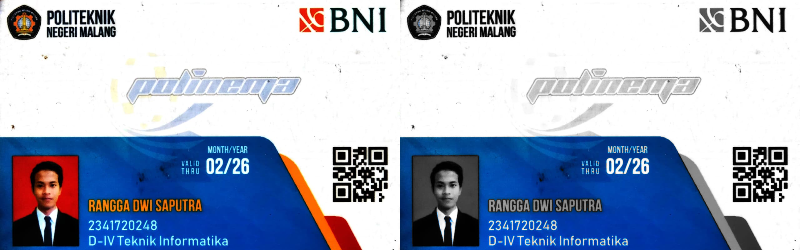

In [9]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

print('Mengubah citra menjadi Grayscale')
print('--------------------------------')
asli = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/ktm.jpg')
img = cv.resize(asli,(400,250))

# Konversi ke HSV untuk threshold warna yang lebih stabil
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Rentang warna biru (nilai umum)
lower_blue = np.array([100, 80, 50])
upper_blue = np.array([140, 255, 255])

# Mask untuk area biru
mask_blue = cv.inRange(hsv, lower_blue, upper_blue)

# Inverse mask untuk bagian yang bukan biru
mask_not_blue = cv.bitwise_not(mask_blue)

# Buat versi grayscale dari gambar asli (convert -> kembali jadi BGR supaya bisa digabung)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Ambil bagian berwarna (hanya biru)
color_part = cv.bitwise_and(img, img, mask=mask_blue)

# Ambil bagian grayscale (hanya area bukan biru)
gray_part = cv.bitwise_and(gray_bgr, gray_bgr, mask=mask_not_blue)

# Gabungkan
result = cv.add(color_part, gray_part)

# Tampilkan perbandingan
comparison = cv.hconcat([img, result])
cv2_imshow(comparison)

## **D2 Operasi Aritmtika dan Logika**

**1. Buat Gamma Correction**

Gamma Correction pada Citra
----------------------------
Masukkan nilai Gamma: 3


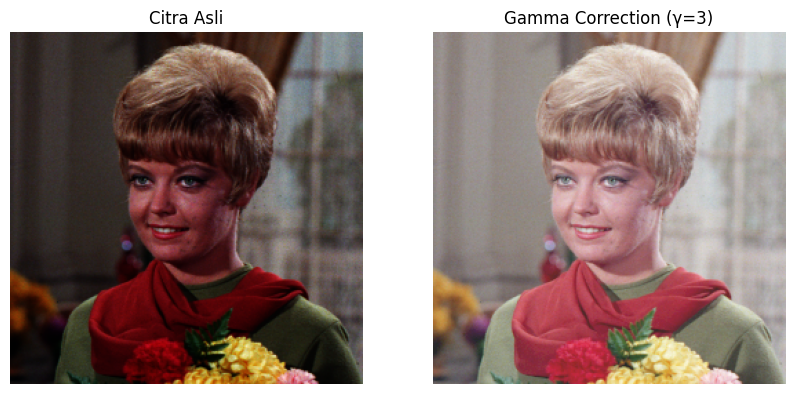

In [15]:
print ('Gamma Correction pada Citra')
print('----------------------------')
try:
  gamma = int(input('Masukkan nilai Gamma: '))
except ValueError :
  print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/female.tiff')


# Normalisasi ke [0,1]
normalized = img / 255.0

gamma_corrected = np.power(normalized, 1.0 / gamma)
gamma_corrected = np.uint8(gamma_corrected * 255)

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(gamma_corrected, cv.COLOR_BGR2RGB))
plt.title(f'Gamma Correction (γ={gamma})')
plt.axis('off')

plt.show()


**2. Simulasi Image Depth**

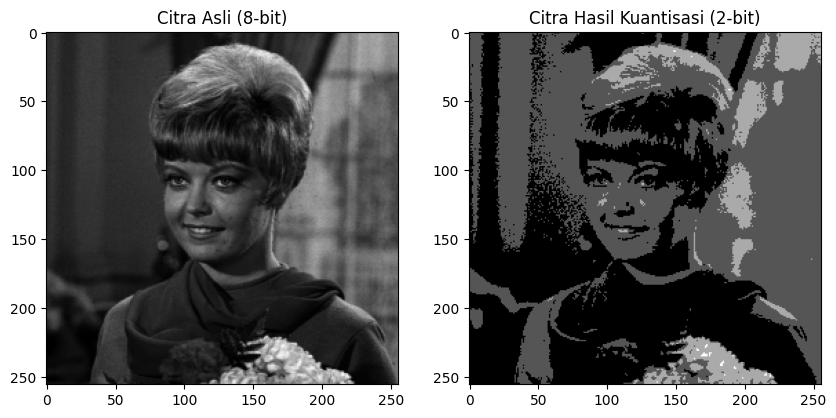

In [17]:
bit_depth=2
level = 255 / (pow(2,bit_depth)-1)
original = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/female.tiff', cv.IMREAD_GRAYSCALE)

# Kuantisasi citra
quantized = np.round(original / level) * level
quantized = np.uint8(quantized)

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title('Citra Asli (8-bit)')

plt.subplot(1,2,2)
plt.imshow(quantized, cmap='gray')
plt.title(f'Citra Hasil Kuantisasi ({bit_depth}-bit)')

plt.show()

**3. Modul Average Denoising**

Jumlah gambar terbaca: 100
PSNR 10 gambar: 19.73562
PSNR 20 gambar: 19.840487
PSNR 20 gambar: 19.892767
PSNR 20 gambar: 19.915894
PSNR 20 gambar: 19.92196


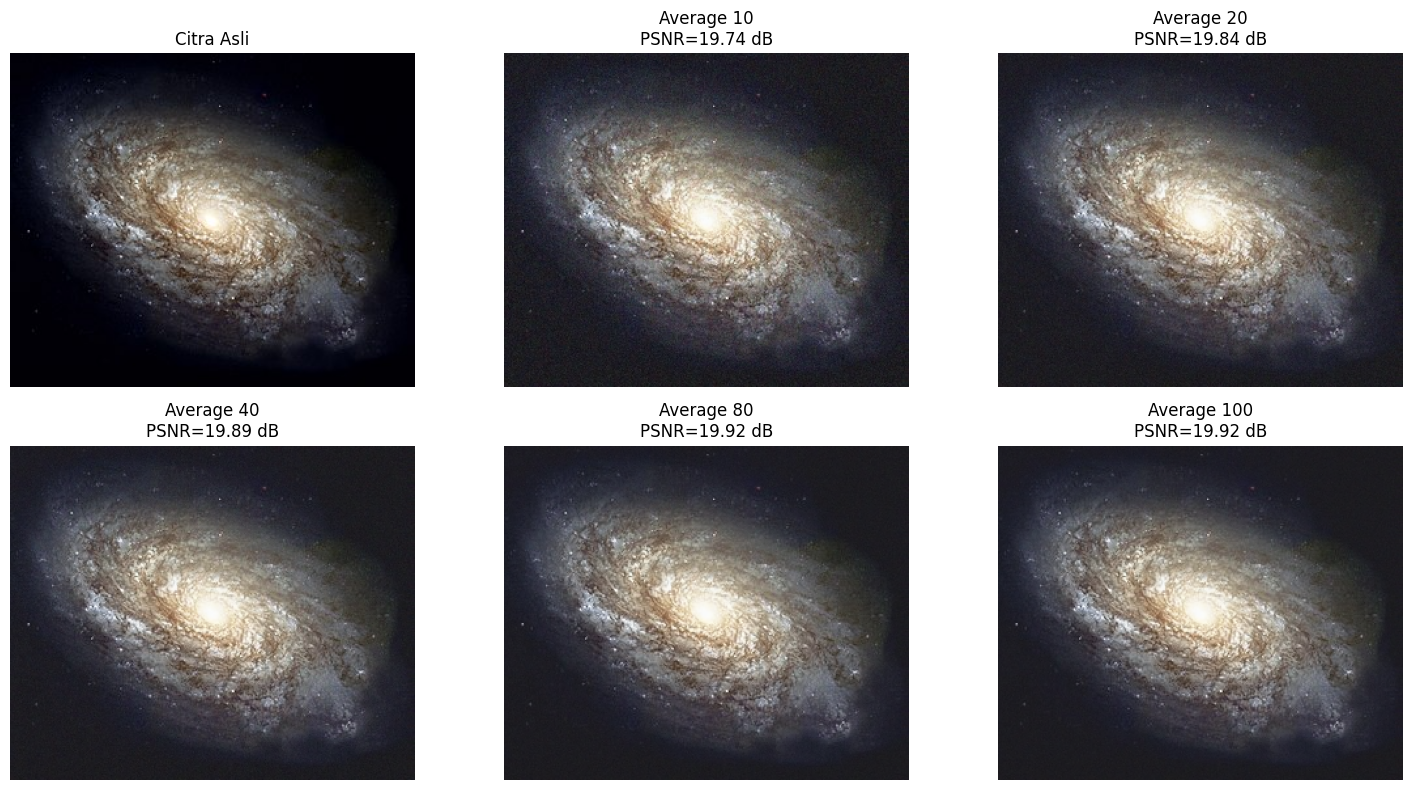

In [8]:
import cv2 as cv
import numpy as np
import glob
import matplotlib.pyplot as plt

# === 1. Baca citra asli ===
original = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/galaxy.jpg')

# === 2. Baca semua citra noise di folder ===
cv_img = []
files = glob.glob('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/noise/*.jpg')
files.sort()  # urutkan biar Salinan 1, Salinan 2, dst

for img in files:
    n = cv.imread(img)
    cv_img.append(n)

print("Jumlah gambar terbaca:", len(cv_img))  # Harusnya 100

# === 3. Fungsi average denoising ===
def average_images(img_list, N):
    avg = np.zeros_like(img_list[0], dtype=np.float32)
    for i in range(N):
        avg += img_list[i].astype(np.float32)
    avg /= N
    return np.uint8(avg)

# === 4. Fungsi PSNR ===
def psnr(target, ref):
    mse = np.mean((target.astype(np.float32) - ref.astype(np.float32)) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

# === 5. Contoh average 10 dan 20 citra ===
denoised10 = average_images(cv_img, 10)
denoised20 = average_images(cv_img, 20)
denoised40 = average_images(cv_img, 40)
denoised80 = average_images(cv_img, 80)
denoised100 = average_images(cv_img, 100)

# === 6. Hitung PSNR ===
psnr10 = psnr(denoised10, original)
psnr20 = psnr(denoised20, original)
psnr40 = psnr(denoised40, original)
psnr80 = psnr(denoised80, original)
psnr100 = psnr(denoised100, original)

print("PSNR 10 gambar:", psnr10)
print("PSNR 20 gambar:", psnr20)
print("PSNR 20 gambar:", psnr40)
print("PSNR 20 gambar:", psnr80)
print("PSNR 20 gambar:", psnr100)

# === 7. Tampilkan hasil dalam 2x3 grid ===
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(cv.cvtColor(denoised10, cv.COLOR_BGR2RGB))
plt.title(f"Average 10\nPSNR={psnr10:.2f} dB")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(cv.cvtColor(denoised20, cv.COLOR_BGR2RGB))
plt.title(f"Average 20\nPSNR={psnr20:.2f} dB")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(cv.cvtColor(denoised40, cv.COLOR_BGR2RGB))
plt.title(f"Average 40\nPSNR={psnr40:.2f} dB")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(cv.cvtColor(denoised80, cv.COLOR_BGR2RGB))
plt.title(f"Average 80\nPSNR={psnr80:.2f} dB")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(cv.cvtColor(denoised100, cv.COLOR_BGR2RGB))
plt.title(f"Average 100\nPSNR={psnr100:.2f} dB")
plt.axis("off")

plt.tight_layout()
plt.show()



Dapat disimpulkan bahwa nilai PSNR (Peak Signal-to-Noise Ratio) meningkat seiring dengan bertambahnya jumlah citra yang digunakan dalam proses averaging (10, 20, 40, 80, hingga 100).

**Kesimpulannya adalah:**

- Semakin banyak jumlah gambar yang di-average, maka hasil citra gabungannya semakin baik (lebih halus, noise berkurang).

- Hal ini ditunjukkan dengan nilai PSNR yang semakin besar (misalnya dari 19.73 dB → 19.92 dB).

- Artinya, proses averaging efektif untuk mengurangi noise dan meningkatkan kualitas citra.

Namun, peningkatan PSNR tidak terlalu signifikan setelah jumlah gambar mencapai titik tertentu (misalnya di atas 80–100 gambar nilainya hampir sama), sehingga ada batas optimal dalam penambahan jumlah citra.

Jadi, semakin banyak jumlah gambar yang di-average, kualitas citra hasil perbaikan semakin baik dengan noise yang lebih rendah, tetapi perbaikannya cenderung menurun (saturasi) setelah titik tertentu.

**4. Image Masking**

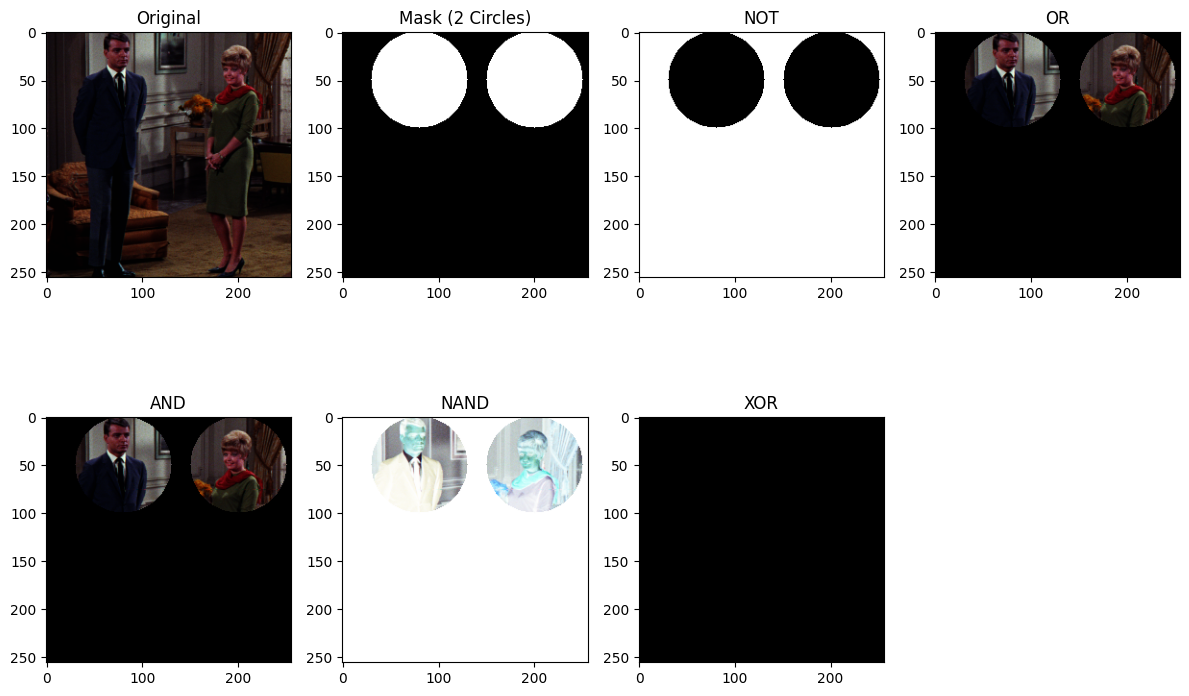

In [23]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra asli
img = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 3/couple.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 2. Buat mask lingkaran
mask = np.zeros(img_gray.shape, dtype="uint8")

# 🔹 Lingkaran pertama
radius1 = 50
cv.circle(mask, (200, 50), radius1, 255, -1)

# 🔹 Lingkaran kedua
radius2 = 50
cv.circle(mask, (80, 50), radius2, 255, -1)

# 3. Operasi logika
not_mask = cv.bitwise_not(mask)
or_img   = cv.bitwise_or(img, img, mask=mask)
and_img  = cv.bitwise_and(img, img, mask=mask)
nand_img = cv.bitwise_not(cv.bitwise_and(img, img, mask=mask))
xor_img  = cv.bitwise_xor(img, img, mask=mask)

# 4. Tampilkan hasil secara manual (tanpa loop)
plt.figure(figsize=(12,8))

plt.subplot(2,4,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(2,4,2)
plt.imshow(mask, cmap='gray')
plt.title('Mask (2 Circles)')

plt.subplot(2,4,3)
plt.imshow(not_mask, cmap='gray')
plt.title('NOT')

plt.subplot(2,4,4)
plt.imshow(cv.cvtColor(or_img, cv.COLOR_BGR2RGB))
plt.title('OR')

plt.subplot(2,4,5)
plt.imshow(cv.cvtColor(and_img, cv.COLOR_BGR2RGB))
plt.title('AND')

plt.subplot(2,4,6)
plt.imshow(cv.cvtColor(nand_img, cv.COLOR_BGR2RGB))
plt.title('NAND')

plt.subplot(2,4,7)
plt.imshow(cv.cvtColor(xor_img, cv.COLOR_BGR2RGB))
plt.title('XOR')

plt.tight_layout()
plt.show()


**Hasil Analisa**
- Mask (2 Circles): Area putih (lingkaran) jadi bagian citra yang diproses, hitam diabaikan.

- NOT: Membalik mask → lingkaran hitam, background putih.

- OR & AND: Sama-sama menampilkan citra hanya di dalam lingkaran, luar lingkaran hitam.

- NAND: Kebalikan dari AND → citra di dalam lingkaran terinvers, luar lingkaran putih.

- XOR: Citra jadi hitam semua karena XOR dengan citra yang sama = 0.